# Avaliação dos modelos de veracidade (FAKO)

Notebook da entrega de documentação e validação do modelo. Ele **carrega** os dois modelos
treinados, **executa** as previsões na validação e no teste e **avalia** os dois com as
mesmas métricas de `pesquisa/ml/avaliar.py`.

| Modelo | Script de treino | Configuração | Artefato |
|---|---|---|---|
| Referência TF-IDF + regressão logística ordinal (Frank e Hall) | `pesquisa/ml/treinar_referencia.py` | `configs/referencia.toml` | `models/2026-11/referencia/referencia.joblib` |
| BERTimbau com cabeça ordinal CORAL | `pesquisa/ml/treinar_bert.py` | `configs/bert.toml` | `models/2026-11/bert/` (`codificador/` + `cabeca_coral.pt`) |

A tarefa é ordinal: `falso` < `enganoso` < `verdadeiro`. Os dois modelos devolvem duas
fronteiras, P1 = P(veracidade > falso) e P2 = P(veracidade > enganoso), e daí saem as três
probabilidades e a nota de 0 a 100.

**Como rodar** (a partir da raiz do repositório, com o dataset em `pesquisa/data/processed/`
e os modelos em `models/`):

```bash
docker compose --profile ml run --rm --no-deps ml sh -c \
  "pip install -q nbconvert ipykernel && jupyter nbconvert --to notebook --execute --inplace pesquisa/notebooks/avaliacao_modelos.ipynb"
```

O teste é olhado aqui uma única vez por modelo, como manda o protocolo do projeto: as
escolhas de hiperparâmetros foram feitas só na validação.

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.metrics import confusion_matrix

# A raiz do repositório: o notebook fica em pesquisa/notebooks/
RAIZ = Path.cwd()
while not (RAIZ / "pesquisa" / "ml").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "pesquisa" / "ml"))

import avaliar
import treinar_referencia
from dados import CLASSES, ORDEM, carregar

PASTA_REFERENCIA = RAIZ / "models" / "2026-11" / "referencia"
PASTA_BERT = RAIZ / "models" / "2026-11" / "bert"
DATASET = RAIZ / "pesquisa" / "data" / "processed" / "dataset.jsonl"
SPLITS = ("validacao", "teste")
print("raiz:", RAIZ)

raiz: /work


## 1. Dados

`dados.carregar()` é a única porta de entrada dos dados de treino: lê o `dataset.jsonl`, usa o
protocolo B (`split_produto`), tira os itens de portal (verdadeiro por suposição), limpa
créditos de veículo e URLs do `texto_curto` e aplica os rótulos da anotação da equipe.

In [2]:
conjunto = carregar("original", DATASET)
print("sha256 do dataset:", conjunto.dataset_sha256[:16])
linhas = ["| split | falso | enganoso | verdadeiro | total |", "|---|---:|---:|---:|---:|"]
for split, contagem in conjunto.contagens().items():
    valores = [contagem.get(c, 0) for c in CLASSES]
    linhas.append(f"| {split} | " + " | ".join(map(str, valores)) + f" | {sum(valores)} |")
display(Markdown("\n".join(linhas)))

sha256 do dataset: 8dc3233220a8a5c5


| split | falso | enganoso | verdadeiro | total |
|---|---:|---:|---:|---:|
| treino | 7221 | 1539 | 1458 | 10218 |
| validacao | 1187 | 964 | 57 | 2208 |
| teste | 1474 | 1092 | 96 | 2662 |

## 2. Carregar os modelos e executar as previsões

As previsões são recalculadas aqui a partir dos artefatos salvos (não lidas do
`previsoes.jsonl`), e depois conferidas contra o que o script de treino gravou.

In [3]:
modelos = {}

referencia = __import__("joblib").load(PASTA_REFERENCIA / "referencia.joblib")
modelos["referencia TF-IDF"] = {
    "pasta": PASTA_REFERENCIA,
    "prever": lambda textos: treinar_referencia.fronteiras(textos, referencia),
    "versao": referencia["versao"],
}

if (PASTA_BERT / "cabeca_coral.pt").exists():
    import treinar_bert

    bert = treinar_bert.carregar_modelo(PASTA_BERT)
    modelos["BERTimbau CORAL"] = {
        "pasta": PASTA_BERT,
        "prever": lambda textos: treinar_bert.fronteiras(textos, bert),
        "versao": bert["versao"],
    }
else:
    print("BERTimbau não encontrado em", PASTA_BERT, "- rode: make bert")

previsoes = {}
for nome, modelo in modelos.items():
    previsoes[nome] = {}
    for split in SPLITS:
        exemplos = conjunto.splits[split]
        inicio = time.perf_counter()
        p1, p2 = modelo["prever"]([e.texto for e in exemplos])
        segundos = time.perf_counter() - inicio
        previsoes[nome][split] = (np.asarray(p1), np.asarray(p2))
        print(f"{nome:18} {split:9} {len(exemplos):5} frases em {segundos:6.1f} s")

    gravadas = avaliar.ler_previsoes(modelo["pasta"])
    exemplos = conjunto.splits["validacao"]
    p1 = previsoes[nome]["validacao"][0]
    diferenca = max(abs(gravadas[e.id][0] - a) for e, a in zip(exemplos, p1) if e.id in gravadas)
    print(f"  {modelo['versao']}: maior diferença de P1 para o previsoes.jsonl = {diferenca:.2e}")

BERTimbau não encontrado em /work/models/2026-11/bert - rode: make bert
referencia TF-IDF  validacao  2208 frases em    0.2 s


referencia TF-IDF  teste      2662 frases em    0.2 s
  referencia-2026-10-07: maior diferença de P1 para o previsoes.jsonl = 0.00e+00


## 3. Métricas gerais

- **F1 macro** (três classes): métrica principal de escolha, porque as classes são desbalanceadas.
- **AUC por fronteira** e **AUC macro**: separação sem depender de limiar.
- **MAE da nota** (0–100) e **kappa quadrático**: o quanto o erro respeita a ordem
  (errar `falso` como `verdadeiro` pesa mais do que como `enganoso`).
- **Recall de falsos com 1% e 5% de alarme falso**: quantos falsos são pegos sem marcar
  verdadeiros como falsos.
- **ECE**: calibração da confiança.

In [4]:
COLUNAS = (
    ("F1 macro", lambda m: m["f1_macro"]),
    ("F1 falso", lambda m: m["f1"].get("falso")),
    ("F1 enganoso", lambda m: m["f1"].get("enganoso")),
    ("F1 verdadeiro", lambda m: m["f1"].get("verdadeiro")),
    ("AUC >falso", lambda m: m["auc_fronteira"][">falso"]),
    ("AUC >enganoso", lambda m: m["auc_fronteira"][">enganoso"]),
    ("AUC macro", lambda m: m["auc_macro"]),
    ("MAE nota", lambda m: m["mae_nota"]),
    ("kappa quad.", lambda m: m["kappa_quadratico"]),
    ("recall falsos @5%", lambda m: m["recall_falsos_5pct"]),
    ("ECE", lambda m: m["ece"]),
)


def formatar(valor):
    return "—" if valor is None else f"{valor:.3f}"


medidas = {}
for split in SPLITS:
    y = np.array([ORDEM[e.veracidade] for e in conjunto.splits[split]])
    linhas = ["| modelo | " + " | ".join(c for c, _ in COLUNAS) + " |",
              "|---|" + "---:|" * len(COLUNAS)]
    for nome in modelos:
        m = avaliar.metricas(y, *previsoes[nome][split])
        medidas[(nome, split)] = m
        linhas.append(f"| {nome} | " + " | ".join(formatar(f(m)) for _, f in COLUNAS) + " |")
    display(Markdown(f"### {split} (n = {len(y)})\n\n" + "\n".join(linhas)))

### validacao (n = 2208)

| modelo | F1 macro | F1 falso | F1 enganoso | F1 verdadeiro | AUC >falso | AUC >enganoso | AUC macro | MAE nota | kappa quad. | recall falsos @5% | ECE |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| referencia TF-IDF | 0.426 | 0.689 | 0.361 | 0.229 | 0.638 | 0.727 | 0.667 | 23.710 | 0.155 | 0.198 | 0.132 |

### teste (n = 2662)

| modelo | F1 macro | F1 falso | F1 enganoso | F1 verdadeiro | AUC >falso | AUC >enganoso | AUC macro | MAE nota | kappa quad. | recall falsos @5% | ECE |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| referencia TF-IDF | 0.411 | 0.679 | 0.346 | 0.208 | 0.580 | 0.729 | 0.630 | 25.217 | 0.131 | 0.096 | 0.138 |

## 4. Matrizes de confusão (teste)

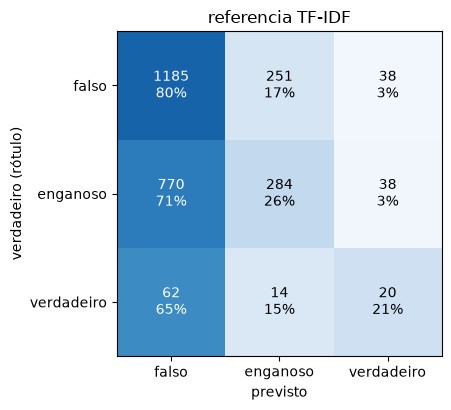

In [5]:
y_teste = np.array([ORDEM[e.veracidade] for e in conjunto.splits["teste"]])
figura, eixos = plt.subplots(1, len(modelos), figsize=(5 * len(modelos), 4.2))
eixos = np.atleast_1d(eixos)
for eixo, nome in zip(eixos, modelos):
    previsto = avaliar.probabilidades(*previsoes[nome]["teste"]).argmax(axis=1)
    matriz = confusion_matrix(y_teste, previsto, labels=[0, 1, 2])
    normalizada = matriz / matriz.sum(axis=1, keepdims=True).clip(min=1)
    eixo.imshow(normalizada, cmap="Blues", vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            cor = "white" if normalizada[i, j] > 0.6 else "black"
            eixo.text(j, i, f"{matriz[i, j]}\n{normalizada[i, j]:.0%}", ha="center", va="center", color=cor)
    eixo.set_xticks(range(3), CLASSES)
    eixo.set_yticks(range(3), CLASSES)
    eixo.set_xlabel("previsto")
    eixo.set_ylabel("verdadeiro (rótulo)")
    eixo.set_title(nome)
plt.tight_layout()
plt.show()

## 5. Margem sobre o teste de atalho

O teste de atalho (`pesquisa/ml/atalho.py`) mede quanto dá para acertar **só pela forma do
texto** (pontuação, maiúsculas, tamanho), sem o conteúdo. Cada base tem uma "cara" própria,
então um modelo pode parecer bom só por reconhecer a fonte. A margem é a AUC macro do modelo
menos a do atalho: quanto maior, mais o modelo aprendeu além da forma.

In [6]:
atalho = json.loads((RAIZ / "pesquisa" / "ml" / "saidas" / "atalho.json").read_text(encoding="utf-8"))
piso = atalho["versoes"]["original"]["splits"]
linhas = ["| modelo | split | AUC macro do modelo | AUC macro do atalho | margem |", "|---|---|---:|---:|---:|"]
for nome in modelos:
    for split in SPLITS:
        modelo, base = medidas[(nome, split)]["auc_macro"], piso.get(split, {}).get("auc_macro")
        if base is not None:
            linhas.append(f"| {nome} | {split} | {modelo:.3f} | {base:.3f} | {modelo - base:+.3f} |")
display(Markdown("\n".join(linhas)))

| modelo | split | AUC macro do modelo | AUC macro do atalho | margem |
|---|---|---:|---:|---:|
| referencia TF-IDF | validacao | 0.667 | 0.663 | +0.004 |
| referencia TF-IDF | teste | 0.630 | 0.664 | -0.034 |

## 6. Desempenho por base (teste)

Mostra onde o modelo acerta e onde falha. Bases com uma classe só (FakeRecogna, FakeTrue.Br)
têm F1 alto por construção e não dizem muito; o desafio real está nas checagens (`factcheck`)
e no FakenewsBR, que têm as três classes.

In [7]:
exemplos = conjunto.splits["teste"]
for nome in modelos:
    p1, p2 = previsoes[nome]["teste"]
    por_split = avaliar.avaliar_split(exemplos, p1, p2, None)
    linhas = ["| base | n | F1 macro | AUC macro | MAE nota |", "|---|---:|---:|---:|---:|"]
    for base, m in sorted(por_split["por_base"].items(), key=lambda item: -item[1]["n"]):
        if m["n"] >= 20:
            linhas.append(f"| {base} | {m['n']} | {formatar(m['f1_macro'])} | {formatar(m['auc_macro'])} | {m['mae_nota']:.1f} |")
    display(Markdown(f"**{nome}**\n\n" + "\n".join(linhas)))

**referencia TF-IDF**

| base | n | F1 macro | AUC macro | MAE nota |
|---|---:|---:|---:|---:|
| factcheck | 2285 | 0.356 | 0.556 | 24.8 |
| fakenewsbr | 197 | 0.411 | 0.683 | 41.2 |
| fakerecogna | 138 | 0.989 | — | 12.1 |
| faketrue | 42 | 0.937 | — | 17.0 |

## 7. Calibração

No diagrama de confiabilidade, um modelo bem calibrado fica sobre a diagonal: quando diz 80%
de confiança, acerta 80% das vezes. Isso importa porque a confiança decide quando o jogo
mostra `incerto` em vez de um veredito.

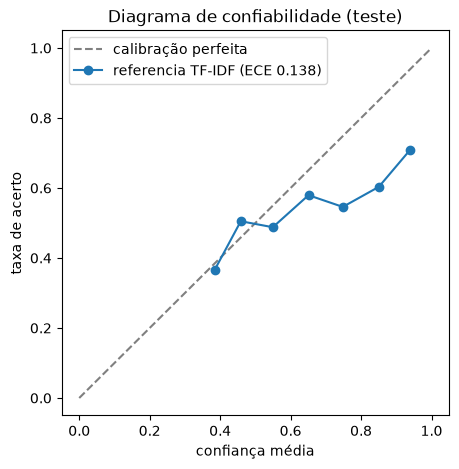

In [8]:
figura, eixo = plt.subplots(figsize=(5, 5))
eixo.plot([0, 1], [0, 1], "--", color="gray", label="calibração perfeita")
for nome in modelos:
    faixas = medidas[(nome, "teste")]["confiabilidade"]
    eixo.plot([f["confianca"] for f in faixas], [f["acerto"] for f in faixas], "o-",
              label=f"{nome} (ECE {medidas[(nome, 'teste')]['ece']:.3f})")
eixo.set_xlabel("confiança média")
eixo.set_ylabel("taxa de acerto")
eixo.set_title("Diagrama de confiabilidade (teste)")
eixo.legend()
plt.show()

## 8. Uso do modelo em frases novas

Exemplo de inferência como na API: uma frase por vez, com as três probabilidades e a nota.

In [9]:
frases = [
    "Vacina contra covid altera o DNA de quem toma",
    "Governo federal anuncia reajuste do salário mínimo para 2025",
    "Vídeo mostra enchente no Rio Grande do Sul em maio de 2024",
]
for nome, modelo in modelos.items():
    p1, p2 = modelo["prever"](frases)
    proba = avaliar.probabilidades(p1, p2)
    linhas = ["| frase | falso | enganoso | verdadeiro | nota | previsto |", "|---|---:|---:|---:|---:|---|"]
    for frase, linha, nota in zip(frases, proba, avaliar.nota(p1, p2)):
        linhas.append(f"| {frase} | {linha[0]:.2f} | {linha[1]:.2f} | {linha[2]:.2f} | {nota:.0f} | {CLASSES[linha.argmax()]} |")
    display(Markdown(f"**{nome}**\n\n" + "\n".join(linhas)))

**referencia TF-IDF**

| frase | falso | enganoso | verdadeiro | nota | previsto |
|---|---:|---:|---:|---:|---|
| Vacina contra covid altera o DNA de quem toma | 0.48 | 0.44 | 0.07 | 30 | falso |
| Governo federal anuncia reajuste do salário mínimo para 2025 | 0.37 | 0.51 | 0.11 | 37 | enganoso |
| Vídeo mostra enchente no Rio Grande do Sul em maio de 2024 | 0.44 | 0.49 | 0.08 | 32 | enganoso |

## 9. Escolha do modelo

Critério definido antes de olhar o teste: maior **F1 macro na validação**, desde que a
**margem sobre o atalho** seja positiva. O teste confirma (ou não) a escolha e estima o
desempenho esperado em dados novos.

In [10]:
escolhido = max(modelos, key=lambda nome: medidas[(nome, "validacao")]["f1_macro"])
for nome in modelos:
    v, t = medidas[(nome, "validacao")], medidas[(nome, "teste")]
    print(f"{nome:18} F1 macro validação {v['f1_macro']:.3f} | teste {t['f1_macro']:.3f} | AUC macro teste {t['auc_macro']:.3f}")
print("\nModelo escolhido pelo critério:", escolhido)

referencia TF-IDF  F1 macro validação 0.426 | teste 0.411 | AUC macro teste 0.630

Modelo escolhido pelo critério: referencia TF-IDF
